In [ ]:
import os

import IPython.display as ipd
import keras
import librosa
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sns
import tensorflow as tf

from keras.models import Sequential
from keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPool2D, Reshape

In [ ]:
# Using the standardized 2-second truncated audio files

train_real_directory = "/content/drive/MyDrive/real_and_fake_audio/for-2seconds/training/real"
train_fake_directory = "/content/drive/MyDrive/real_and_fake_audio/for-2seconds/training/fake"

validation_real_directory = "/content/drive/MyDrive/real_and_fake_audio/for-2seconds/validation/real"
validation_fake_directory = "/content/drive/MyDrive/real_and_fake_audio/for-2seconds/validation/fake"

test_real_directory = "/content/drive/MyDrive/real_and_fake_audio/for-2seconds/testing/real"
test_fake_directory = "/content/drive/MyDrive/real_and_fake_audio/for-2seconds/testing/fake"

In [ ]:
# Get waveform (.wav) audio files

train_real_audio = [os.path.join(train_real_directory, file) for file in os.listdir(train_real_directory) if file.endswith('.wav')]
train_fake_audio = [os.path.join(train_fake_directory, file) for file in os.listdir(train_fake_directory) if file.endswith('.wav')]

validation_real_audio = [os.path.join(validation_real_directory, file) for file in os.listdir(validation_real_directory) if file.endswith('.wav')]
validation_fake_audio = [os.path.join(validation_fake_directory, file) for file in os.listdir(validation_fake_directory) if file.endswith('.wav')]

test_real_audio = [os.path.join(test_real_directory, file) for file in os.listdir(test_real_directory) if file.endswith('.wav')]
test_fake_audio = [os.path.join(test_fake_directory, file) for file in os.listdir(test_fake_directory) if file.endswith('.wav')]

In [ ]:
# Taking a random audio file
random_audio_file = train_real_audio[random.randint(0, 6977)]
ipd.Audio(random_audio_file)

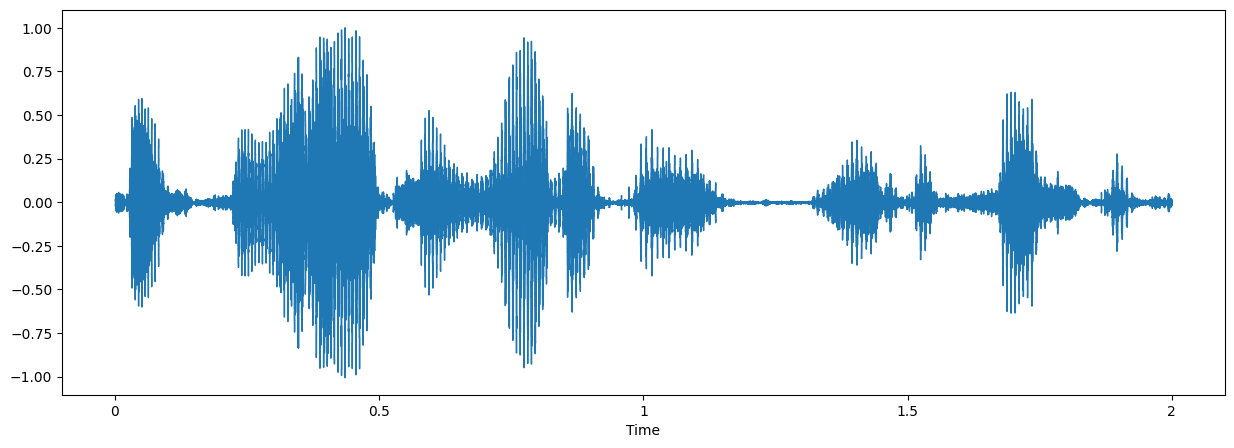

In [ ]:
# Visualize waveform of sample audio above
# sr (sample rate) refers to the frequency of "snapshots" of the audio used for digital representation
audio_data, sample_rate = librosa.load(random_audio_file)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(audio_data, sr=sample_rate)

In [ ]:
def create_mel_spectrogram(file_path):
    audio_data, sample_rate = librosa.load(file_path)
    # Convert audio to mel-based spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate)
    # Convert from amplitude squared to decibel units
    mel_decibel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    return mel_decibel_spectrogram

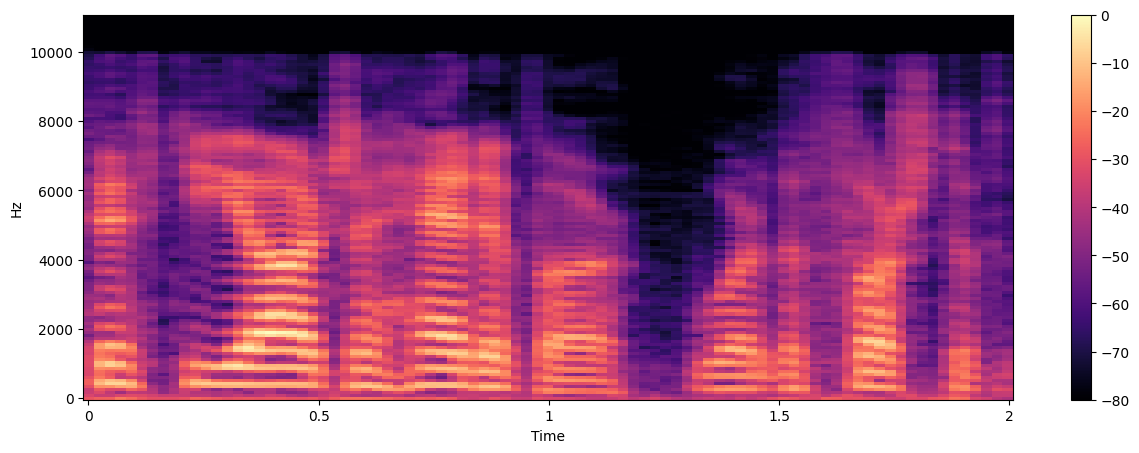

In [ ]:
# Spectrogram representation of the sample wave form above
sample_spectrogram = create_mel_spectrogram(random_audio_file)
plt.figure(figsize=(15, 5))
librosa.display.specshow(sample_spectrogram, x_axis='time', y_axis='hz')
plt.colorbar()

In [ ]:
import tqdm

# Use spectrograms as features to train the model
def get_features_and_labels(real_audio_files, fake_audio_files):
    spec_arr = []
    labels = []

    for file in tqdm.tqdm(real_audio_files, desc="Processing Real Audio"): # Added tqdm
        spectrogram = create_mel_spectrogram(file)
        spec_arr.append(spectrogram)
        labels.append(0)
    for file in tqdm.tqdm(fake_audio_files, desc="Processing Fake Audio"): # Added tqdm
        spectrogram = create_mel_spectrogram(file)
        spec_arr.append(spectrogram)
        labels.append(1)

    return np.array(spec_arr), np.array(labels)

train_features, train_labels = get_features_and_labels(train_real_audio, train_fake_audio)
validation_features, validation_labels = get_features_and_labels(validation_real_audio, validation_fake_audio)
test_features, test_labels = get_features_and_labels(test_real_audio, test_fake_audio)

Processing Fake Audio: 100%|██████████| 544/544 [03:15<00:00,  2.79it/s]


In [ ]:
print("train features shape: {}".format(train_features.shape))
print("test features shape: {}".format(test_features.shape))

train features shape: (13956, 128, 87)
test features shape: (1088, 128, 87)


In [ ]:
# Significantly trimmed VGG model to optimize results

trimmed_vgg = Sequential()
trimmed_vgg.add(Reshape((128, 87, 1),input_shape=train_features.shape[1:]))

trimmed_vgg.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

trimmed_vgg.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation='relu'))
trimmed_vgg.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

trimmed_vgg.add(Flatten())
trimmed_vgg.add(Dense(units=256,activation="relu"))
trimmed_vgg.add(Dense(units=256,activation="relu"))
trimmed_vgg.add(Dense(1, activation="sigmoid"))

trimmed_vgg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 128, 87, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 87, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 87, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 43, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,020,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,345,409 (85.24 MB)

 Trainable params: 22,345,409 (85.24 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
# Adam optimiser helps model get unstuck when stuck at local minima
trimmed_vgg.compile(optimizer=keras.optimizers.Adam(),
                    loss=keras.losses.binary_crossentropy,
                    metrics=["accuracy"])

In [ ]:
trimmed_vgg_history = trimmed_vgg.fit(train_features,
                                      train_labels,
                                      validation_data = [validation_features, validation_labels],
                                      batch_size = 32,
                                      epochs = 30,
                                      steps_per_epoch = 300)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.5090 - loss: 5.3205 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/30
137/300 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.5065 - loss: 0.6931

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.5005 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.4872 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.5034 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.4902 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.4917 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.4928 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 9/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.5023 - loss: 0.6932 - val_accuracy: 

In [ ]:
# Saving the final version

trimmed_vgg.save('/content/drive/MyDrive/real_and_fake_audio/deepfake_audio_detector.h5')

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# Get raw model output (probabilities in this case, due to sigmoid activation)
probabilities = trimmed_vgg.predict(validation_features)

# Convert probabilities to class indices using a threshold (0.5 for binary classification)
y_pred = (probabilities >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(validation_labels, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
cr = classification_report(validation_labels, y_pred)
print("Classification Report:\n", cr)

# Accuracy
acc = accuracy_score(validation_labels, y_pred)
print("Accuracy:", acc)

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Confusion Matrix:
 [[1409    4]
 [   9 1404]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1413
           1       1.00      0.99      1.00      1413

    accuracy                           1.00      2826
   macro avg       1.00      1.00      1.00      2826
weighted avg       1.00      1.00      1.00      2826

Accuracy: 0.9953998584571833


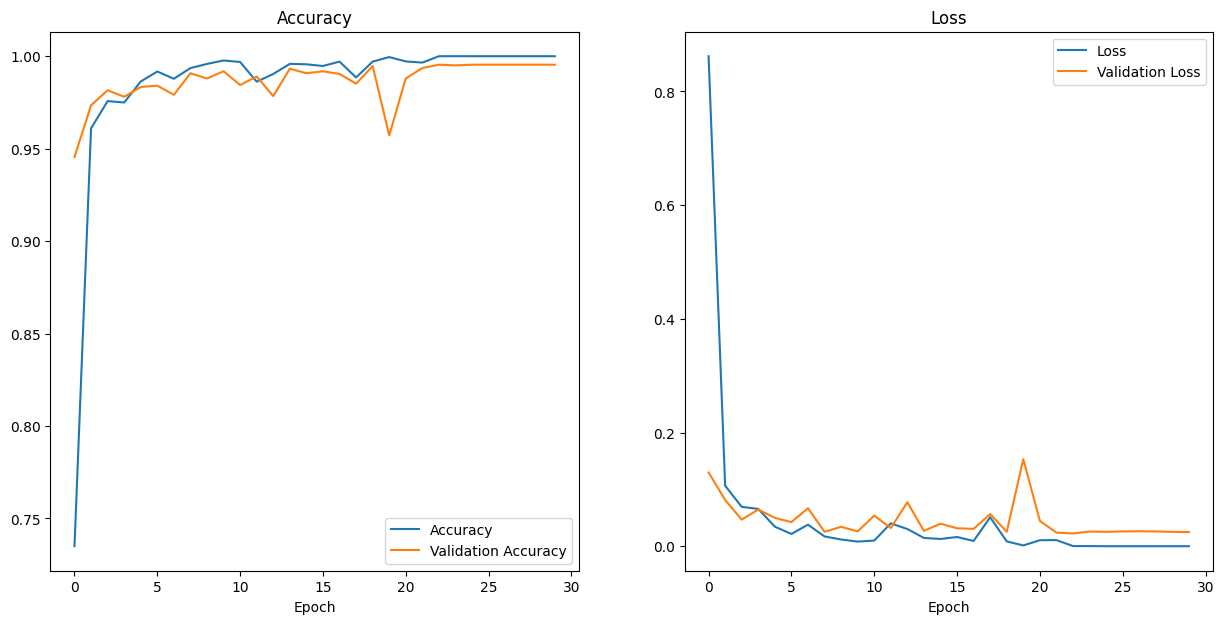

In [ ]:
# Note that extremely high accuracy is not due to model overfitting,
# it's because the dataset is very "easy" relative to actual modern state of deepfaked audio
# i.e. the fakes are mostly easily detectable, even to the human ear

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(trimmed_vgg_history.history["accuracy"])
ax1.plot(trimmed_vgg_history.history['val_accuracy'])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend(["Accuracy","Validation Accuracy"])

ax2.plot(trimmed_vgg_history.history["loss"])
ax2.plot(trimmed_vgg_history.history["val_loss"])
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend(["Loss","Validation Loss"])

plt.show()

### Demonstrating Incorrect Predictions

### Correct Prediction Code for New Audio

In [ ]:
import tensorflow as tf
import librosa
import numpy as np
import IPython.display as ipd
from google.colab import files # Import files for uploading

# ================= LOAD MODEL =================
MODEL_PATH = "/content/drive/MyDrive/real_and_fake_audio/deepfake_audio_detector.h5"

try:
    # Only load the model if it hasn't been loaded already
    if 'model' not in locals() or model is None:
        model = tf.keras.models.load_model(MODEL_PATH)
        print("Model loaded successfully.")
    else:
        print("Model already loaded.")
except Exception as e:
    print(f"Error loading model: {e}")
    model = None

# ================= PREPROCESS FUNCTION =================
# This function preprocesses the audio to match the training data format
def preprocess_audio(file_path, sr=22050, n_mels=128, max_len=87):
    y, sr = librosa.load(file_path, sr=sr)

    # trim silence (safe, does not change shape logic)
    y, _ = librosa.effects.trim(y, top_db=20)

    # amplitude normalize
    y = y / (np.max(np.abs(y)) + 1e-9)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # FORCE EXACT SHAPE USED IN TRAINING
    if mel_db.shape[1] < max_len:
        padding = max_len - mel_db.shape[1]
        mel_db = np.pad(
            mel_db,
            ((0, 0), (0, padding))
        )
    else:
        mel_db = mel_db[:, :max_len]

    return mel_db


# ================= PREDICTION ON NEW AUDIO =================
# Upload a new audio file for prediction:
print("Please upload an audio file for prediction:")
uploaded_new = files.upload()

if uploaded_new:
    new_audio_file_path = list(uploaded_new.keys())[0]

    if model is not None:
        print(f"Playing audio: {new_audio_file_path}")
        ipd.display(ipd.Audio(new_audio_file_path))

        # Preprocess the uploaded audio
        mel_spec_new = preprocess_audio(new_audio_file_path)

        # Reshape for model input (add batch and channel dimensions)
        X_new = mel_spec_new[np.newaxis, ..., np.newaxis]  # (1, 128, 87, 1)

        # Make prediction
        prediction_new = model.predict(X_new, verbose=0)
        # Convert probability to binary label using a 0.5 threshold
        label_new = int(prediction_new[0][0] >= 0.5)

        print(f"Raw prediction probability: {prediction_new[0][0]:.6f}")
        if label_new == 1:
            print("Prediction: FAKE AUDIO")
        else:
            print("Prediction: REAL AUDIO")
    else:
        print("Model not loaded. Cannot make prediction.")
else:
    print("No audio file uploaded for prediction.")

Model already loaded.
Please upload an audio file for prediction:


Saving file243.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav to file243.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
Playing audio: file243.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav


Raw prediction probability: 1.000000
Prediction: FAKE AUDIO
